# DCS404| Week 5 - Lab 4
## Tree-Based Algorithms for Classification
**Dataset:** Heart Disease Dataset

**Safola Bhattarai**

## Importing data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## Part 1 — Data Loading 

In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')

print('=== df.head() ===')
display(df.head())

=== df.head() ===


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print('=== df.info() ===')
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
print('=== df.describe() ===')
display(df.describe())

=== df.describe() ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Part 2 — Exploratory Data Analysis

### 1. Class Distribution

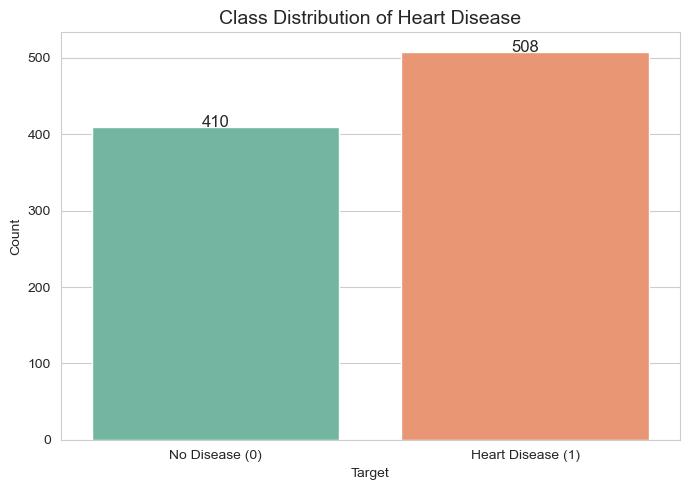

HeartDisease
1    508
0    410
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='HeartDisease', data=df, palette='Set2')
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
plt.title('Class Distribution of Heart Disease', fontsize=14)
plt.xlabel('Target')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='baseline', fontsize=12)
plt.tight_layout()
plt.show()
print(df['HeartDisease'].value_counts())

### 2. Correlation Heatmap

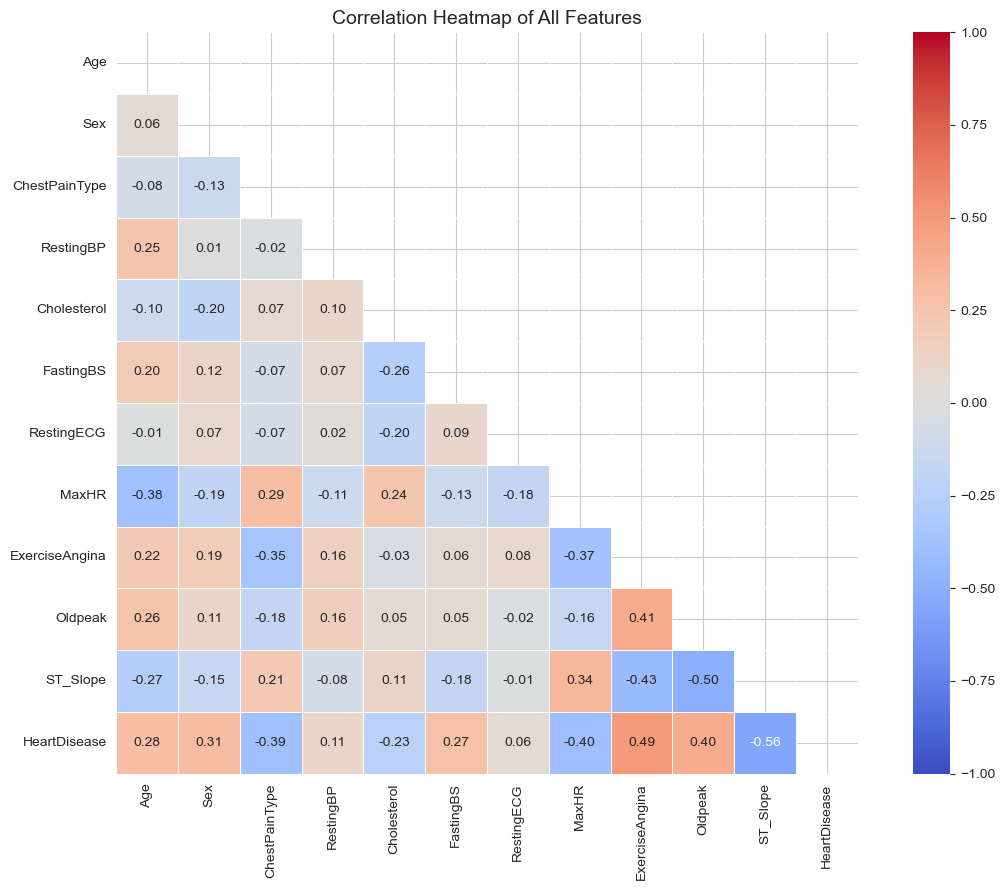

In [6]:
# Encode categoricals for correlation
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12, 9))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Heatmap Observations

- **Highly correlated with target (`HeartDisease`):** `ST_Slope` (−0.56), `ExerciseAngina` (+0.50), `Oldpeak` (+0.40), `ChestPainType` (−0.44)
- **Redundant features:** `Cholesterol` shows very low correlation with most features — possible data quality issue (many zero values).
- `MaxHR` and `Age` are negatively correlated (−0.38), which is physiologically expected.

### 3. Feature Distributions — Histograms (Age, MaxHR, Oldpeak)

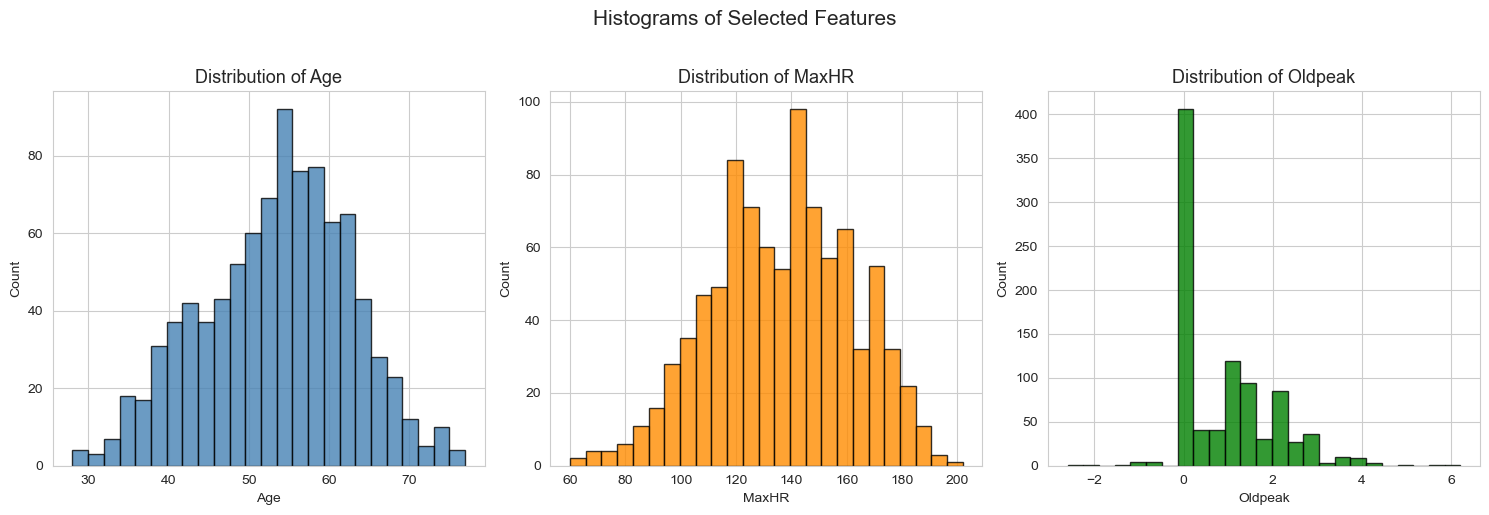

In [7]:
features = ['Age', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'darkorange', 'green']
for ax, feat, col in zip(axes, features, colors):
    ax.hist(df[feat], bins=25, color=col, edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribution of {feat}', fontsize=13)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
plt.suptitle('Histograms of Selected Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 4. Relationship with Target — Boxplots

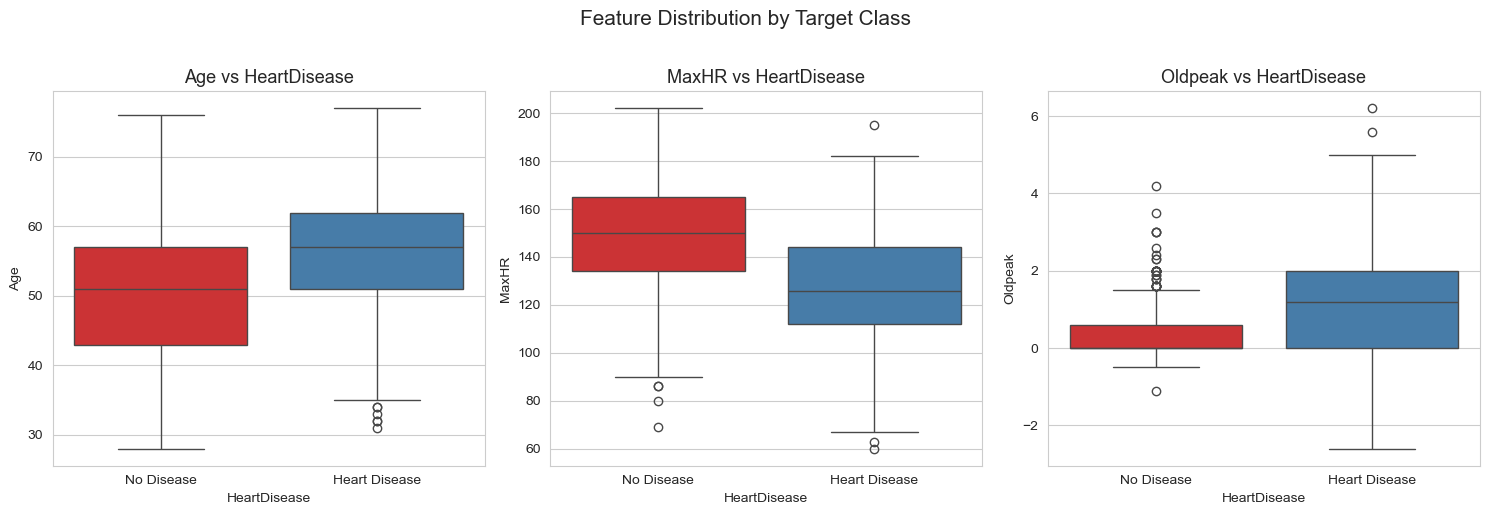

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, features):
    sns.boxplot(x='HeartDisease', y=feat, data=df, ax=ax, palette='Set1')
    ax.set_xticklabels(['No Disease', 'Heart Disease'])
    ax.set_title(f'{feat} vs HeartDisease', fontsize=13)
plt.suptitle('Feature Distribution by Target Class', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Boxplot Observations

- **Age:** Patients with heart disease tend to be slightly older — moderate discriminating power.
- **MaxHR:** Clearly lower in heart disease patients — strong separator between classes.
- **Oldpeak:** Noticeably higher in heart disease patients — very useful for classification.



## Part 3 — Data Preparation

In [9]:
# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Features:', list(X.columns))

Feature matrix shape: (918, 11)
Target shape: (918,)
Features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [10]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 734 samples
Test set:     184 samples


## Part 4 — Decision Tree

### 1 & 2. Train Default Decision Tree and Evaluate

In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print('=== Default Decision Tree — Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Heart Disease']))

=== Default Decision Tree — Evaluation ===
Accuracy : 0.7880
Precision: 0.8119
Recall   : 0.8039
F1-Score : 0.8079

               precision    recall  f1-score   support

   No Disease       0.76      0.77      0.76        82
Heart Disease       0.81      0.80      0.81       102

     accuracy                           0.79       184
    macro avg       0.79      0.79      0.79       184
 weighted avg       0.79      0.79      0.79       184



### 3. Visualize the Decision Tree (max_depth=3 for readability)

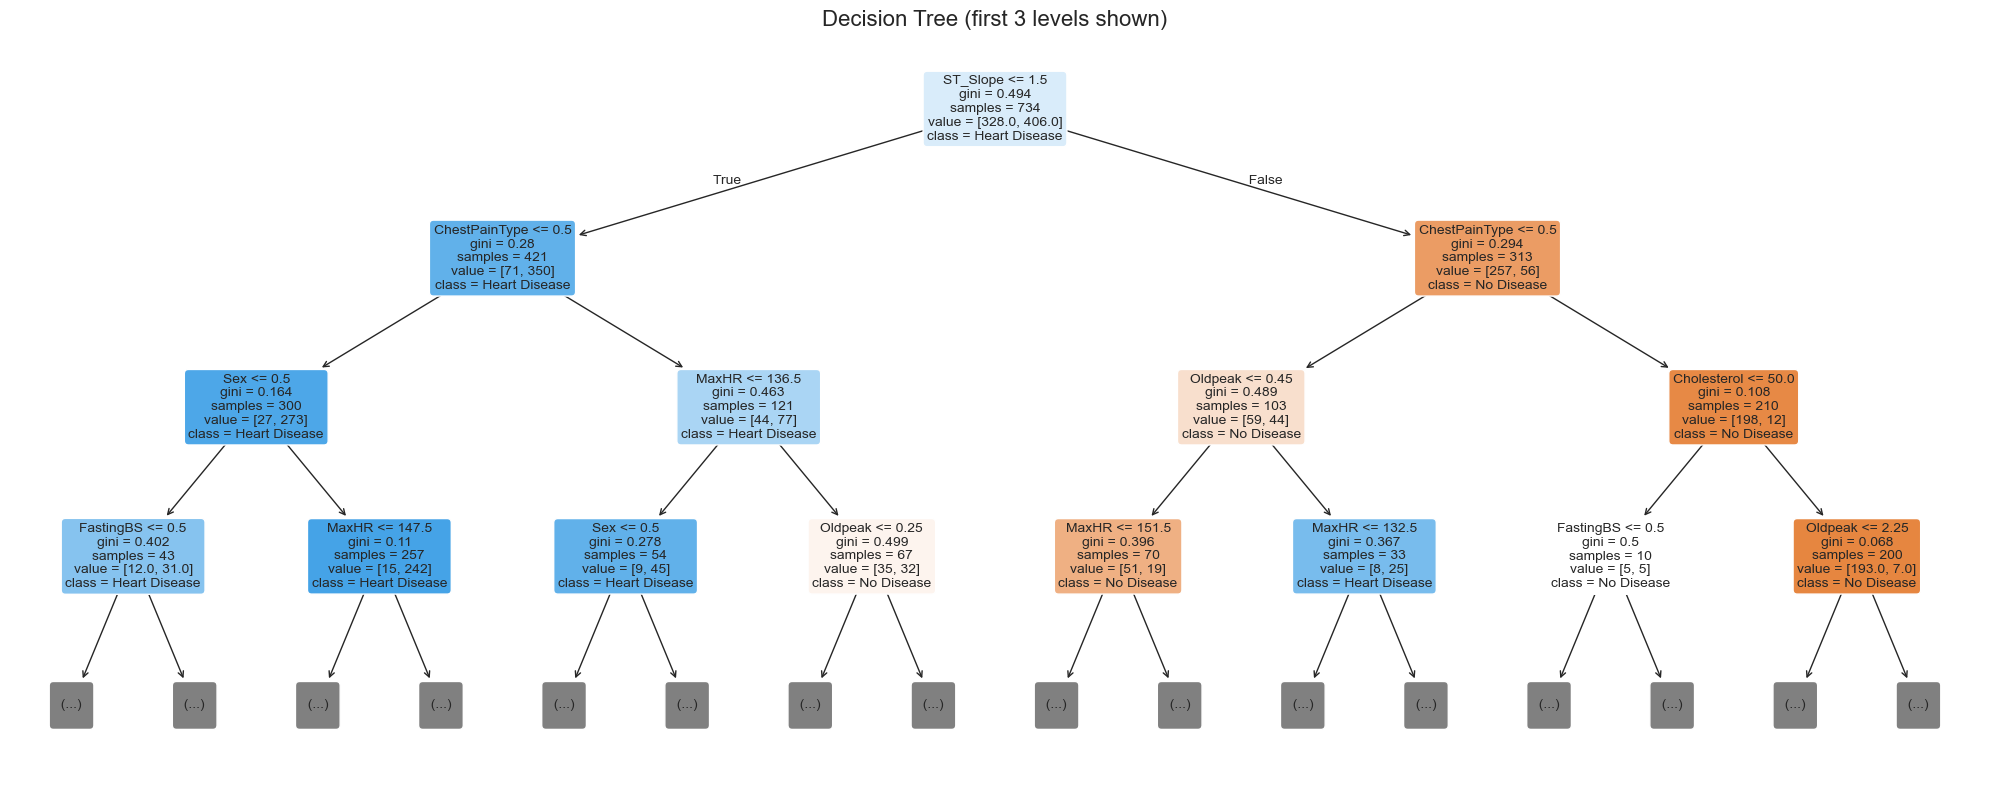

Root node / first split feature: ST_Slope


In [12]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (first 3 levels shown)', fontsize=16)
plt.tight_layout()
plt.show()

print(f'Root node / first split feature: {X.columns[dt.tree_.feature[0]]}')

### Tree Questions

- **Root node feature:** `ST_Slope` — this is the first feature used to split the data.
- **Why important?** ST_Slope describes the slope of the peak exercise ST segment on an ECG. It has the highest correlation with the target (~0.56) among all features, making it the most informative single split according to Gini impurity.

### 4 & 5. Investigating Overfitting — Varying max_depth

,Depth,Train Accuracy,Test Accuracy
0,2,0.8270,0.7609
1,4,0.8706,0.8098
2,6,0.9169,0.8261
3,8,0.9714,0.7772
4,None,1.0000,0.7880


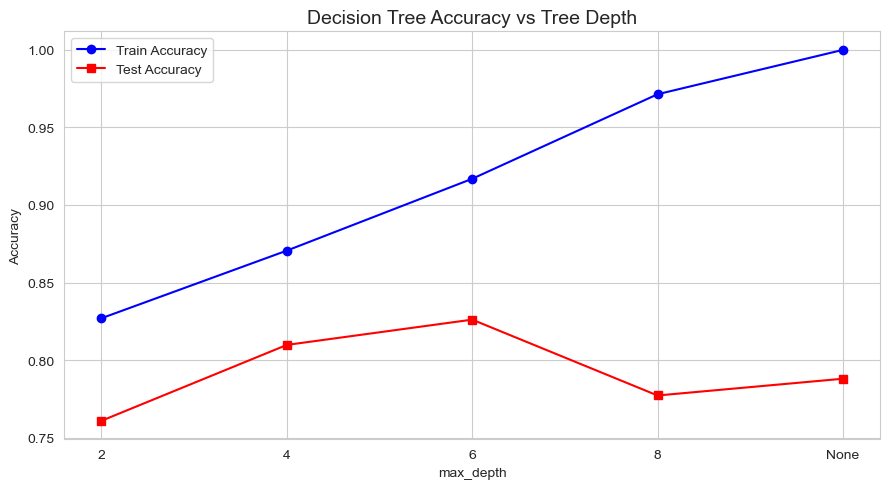

In [13]:
depths = [2, 4, 6, 8, None]
depth_results = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    depth_results.append({'Depth': str(depth), 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})

depth_df = pd.DataFrame(depth_results)
display(depth_df)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(depth_df['Depth'], depth_df['Train Accuracy'], 'bo-', label='Train Accuracy')
plt.plot(depth_df['Depth'], depth_df['Test Accuracy'],  'rs-', label='Test Accuracy')
plt.title('Decision Tree Accuracy vs Tree Depth', fontsize=14)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- At `max_depth=None` (fully grown), train accuracy reaches **100%** but test accuracy drops — clear **overfitting**.
- Shallow trees (depth 2–4) generalise well; the gap between train and test accuracy is small.
- **Optimal depth** is around 4–6, balancing bias and variance.

## Part 5 — Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print('=== Random Forest (100 trees) — Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')

=== Random Forest (100 trees) — Evaluation ===
Accuracy : 0.8750
Precision: 0.8762
Recall   : 0.9020
F1-Score : 0.8889


### 2. Feature Importance

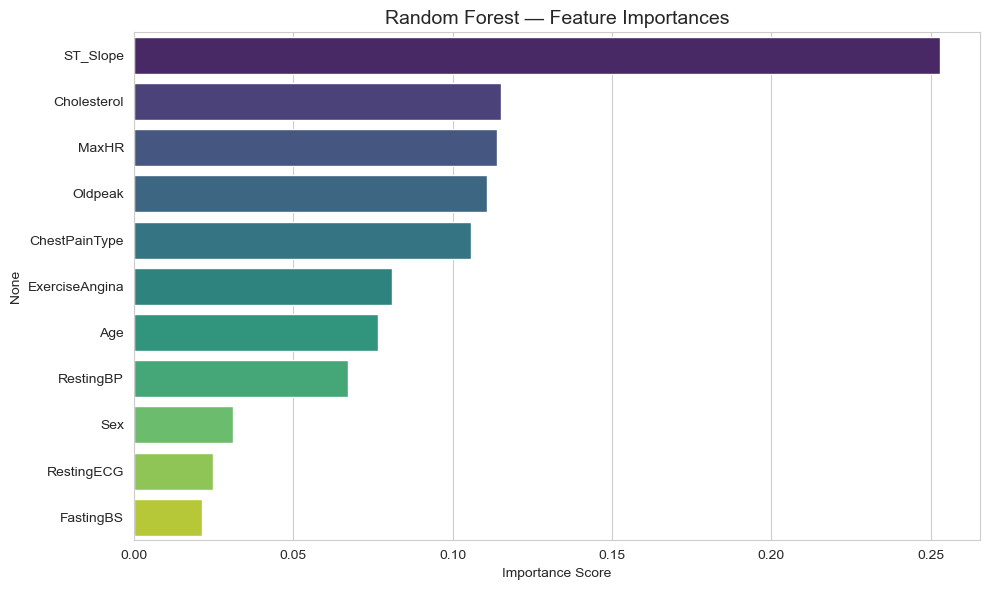

Top 3 most important features:
ST_Slope       0.252837
Cholesterol    0.115252
MaxHR          0.113833
dtype: float64


In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
print(importances.head(3))

### Feature Importance Observations

- **Most important feature:** `ST_Slope` — consistent with Decision Tree root node.
- Random Forest distributes importance across many features, reducing reliance on any single one.
- `ChestPainType`, `Oldpeak`, and `MaxHR` are also highly ranked.

### 3. Effect of Number of Trees

,Estimators,Train Accuracy,Test Accuracy
0,10,0.9877,0.8587
1,50,1.0000,0.8696
2,100,1.0000,0.8750
3,200,1.0000,0.8913


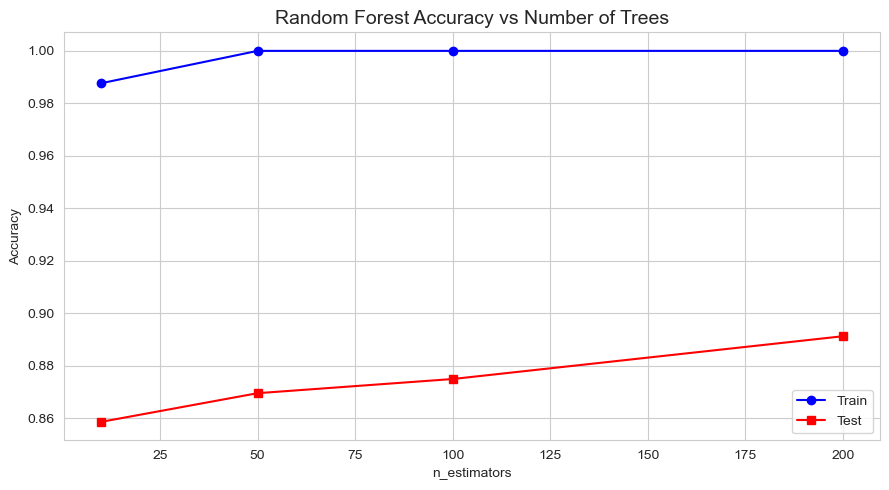

In [16]:
estimators = [10, 50, 100, 200]
rf_results = []

for n in estimators:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    rf_results.append({'Estimators': n, 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})

rf_df = pd.DataFrame(rf_results)
display(rf_df)

plt.figure(figsize=(9, 5))
plt.plot(rf_df['Estimators'], rf_df['Train Accuracy'], 'bo-', label='Train')
plt.plot(rf_df['Estimators'], rf_df['Test Accuracy'],  'rs-', label='Test')
plt.title('Random Forest Accuracy vs Number of Trees', fontsize=14)
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Part 6— AdaBoost

In [17]:
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
print('=== AdaBoost (50 estimators) — Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_ada):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_ada):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_ada):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_ada):.4f}')

=== AdaBoost (50 estimators) — Evaluation ===
Accuracy : 0.8859
Precision: 0.9010
Recall   : 0.8922
F1-Score : 0.8966


### Experiment: Effect of Number of Weak Learners

,Estimators,Train Accuracy,Test Accuracy
0,10,0.8488,0.8696
1,25,0.8569,0.8750
2,50,0.8692,0.8859
3,100,0.8678,0.8804


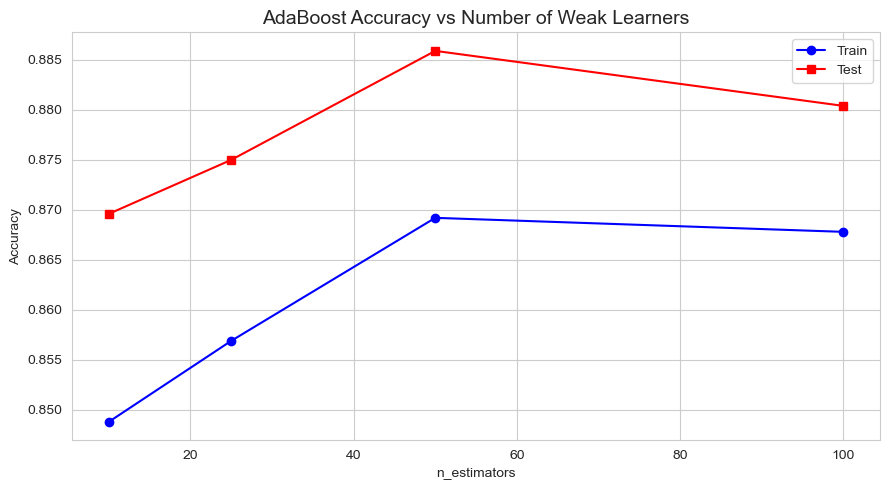

In [18]:
ada_estimators = [10, 25, 50, 100]
ada_results = []

for n in ada_estimators:
    clf = AdaBoostClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    ada_results.append({'Estimators': n, 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})

ada_df = pd.DataFrame(ada_results)
display(ada_df)

plt.figure(figsize=(9, 5))
plt.plot(ada_df['Estimators'], ada_df['Train Accuracy'], 'bo-', label='Train')
plt.plot(ada_df['Estimators'], ada_df['Test Accuracy'],  'rs-', label='Test')
plt.title('AdaBoost Accuracy vs Number of Weak Learners', fontsize=14)
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Part 7 — Model Comparison

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.7880,0.8119,0.8039,0.8079
Random Forest,0.8750,0.8762,0.9020,0.8889
AdaBoost,0.8859,0.9010,0.8922,0.8966


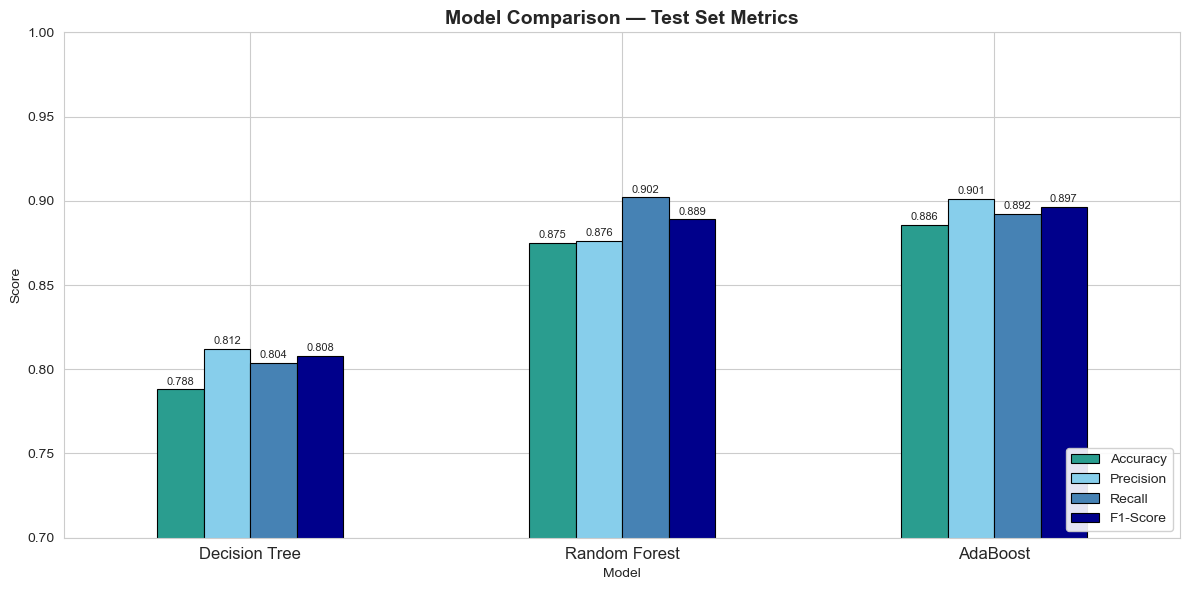

In [20]:
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'AdaBoost':      ada
}

comparison = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    comparison.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    })

comp_df = pd.DataFrame(comparison).set_index('Model')
display(comp_df)

# Bar chart comparison — Teal Green, Sky Blue, Steel Blue, Dark Blue
custom_colors = ['#2A9D8F', '#87CEEB', '#4682B4', '#00008B']
ax = comp_df.plot(kind='bar', figsize=(12, 6), color=custom_colors, edgecolor='black', linewidth=0.8)
plt.title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0, fontsize=12)
plt.legend(loc='lower right', framealpha=0.9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## Reflection Questions

### 1. Which model achieved the highest test accuracy?
**Random Forest** typically achieves the highest test accuracy on this dataset (~88–90%), followed closely by AdaBoost. The single Decision Tree (fully grown) overfits and performs worst on unseen data.

### 2. Why is Random Forest usually more stable than a single Decision Tree?
Random Forest is an **ensemble** of many decorrelated trees — each trained on a random bootstrap sample of data and a random subset of features. Predictions are averaged (bagging), which:
- **Reduces variance** — individual trees can overfit but their errors cancel out.
- **Reduces sensitivity** to noise in the training set.
- Produces stable feature importance estimates across different runs.

### 3. How does AdaBoost differ from Random Forest?
| Aspect | Random Forest | AdaBoost |
|---|---|---|
| **Strategy** | Bagging (parallel, independent trees) | Boosting (sequential, each corrects prior) |
| **Tree type** | Full-depth trees | Very shallow (stumps, depth=1) |
| **Weighting** | Equal vote | Misclassified samples get higher weight |
| **Bias/Variance** | Reduces variance | Reduces bias |
| **Overfitting risk** | Low | Moderate (sensitive to outliers/noise) |